In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("datasets/train.csv")
M, N = df.shape
df.head(5)

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


### Analysis of the number and nature of missing values

In [3]:
# first, find all potentially invalid data
borders = {"sleep_duration": [0.0, 24.0], "heart_rate": [0.0, 220.0], "bmi": [0.0, 100],
           "calorie_expenditure": [0.0, np.inf], "step_count": [0.0, np.inf], 
           "exercise_duration": [0.0, 1440.0], "water_intake": [0.0, np.inf],
           "diet_type": ("veg", "non-veg", "balanced"), "stress_level": ("low", "high", "medium"),
           "sleep_quality": ('average', 'poor', 'good'), "physical_activity_level": ('sedentary', 'moderate', 'active'),
           "smoking_alcohol": ('yes', 'occasional', 'no'), "gender": ('female', 'other', 'male')}

for col_name in df.columns:
    if col_name not in borders:
        continue
    else:
        try:
            if type(borders[col_name]) is tuple:
                mask = ~(df[col_name].isin(borders[col_name]) | df[col_name].isna())
            elif type(borders[col_name]) is list:
                mask = ~(((df[col_name] >= borders[col_name][0]) & (df[col_name] <= borders[col_name][1])) | df[col_name].isna())
            else:
                raise AttributeError("Non-standard data type in the borders dict")
        except AttributeError as ae:
            print(f"borders dict is corrupted: {ae}")
        
            

### Conclusion
All values lie within valid ranges

In [4]:
df.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [5]:
missing_per_row = df.isnull().sum(axis=1)
missing_counts = [[num, np.round(num/M, 2)] for num in missing_per_row.value_counts().sort_index()]
print("Number of rows by missing-value count (count, share of the whole df):")
print(*missing_counts, sep="\n")

Number of rows by missing-value count (count, share of the whole df):
[349623, np.float64(0.51)]
[248134, np.float64(0.36)]
[77311, np.float64(0.11)]
[13445, np.float64(0.02)]
[1479, np.float64(0.0)]
[87, np.float64(0.0)]
[9, np.float64(0.0)]


In [6]:
# since the overall share of samples with 3+ missing values is <= 0.2, we drop them
print((df.isnull().sum(axis=1) >= 3).sum())
df = df[~(df.isnull().sum(axis=1) >= 3)]

15020


Next, we need to handle the categorical features. We use One-Hot Encoding

In [7]:
# Replace NaN with median values
from sklearn.preprocessing import OneHotEncoder

columns_categor = ["diet_type", "stress_level", "sleep_quality", "physical_activity_level", "smoking_alcohol", "gender"]

df_Y = df[["id", "health_condition"]].copy()
df.drop(columns=["id", "health_condition"], inplace=True)

df_numerical = df.drop(columns=columns_categor)
df_numerical = df_numerical.fillna(df_numerical.median())

df_categorical = df[columns_categor].fillna("Missing")
encoder = OneHotEncoder(sparse_output=False)
df_categorical_encoded = encoder.fit_transform(df_categorical)

df_categorical = pd.DataFrame(
    df_categorical_encoded,
    columns=encoder.get_feature_names_out(columns_categor),
    index=df_categorical.index 
)

df = pd.concat([df_Y, df_numerical, df_categorical], axis=1)

print(df.isna().sum())

id                                   0
health_condition                     0
sleep_duration                       0
heart_rate                           0
bmi                                  0
calorie_expenditure                  0
step_count                           0
exercise_duration                    0
water_intake                         0
diet_type_Missing                    0
diet_type_balanced                   0
diet_type_non-veg                    0
diet_type_veg                        0
stress_level_Missing                 0
stress_level_high                    0
stress_level_low                     0
stress_level_medium                  0
sleep_quality_Missing                0
sleep_quality_average                0
sleep_quality_good                   0
sleep_quality_poor                   0
physical_activity_level_Missing      0
physical_activity_level_active       0
physical_activity_level_moderate     0
physical_activity_level_sedentary    0
smoking_alcohol_Missing  

#### Distribution check

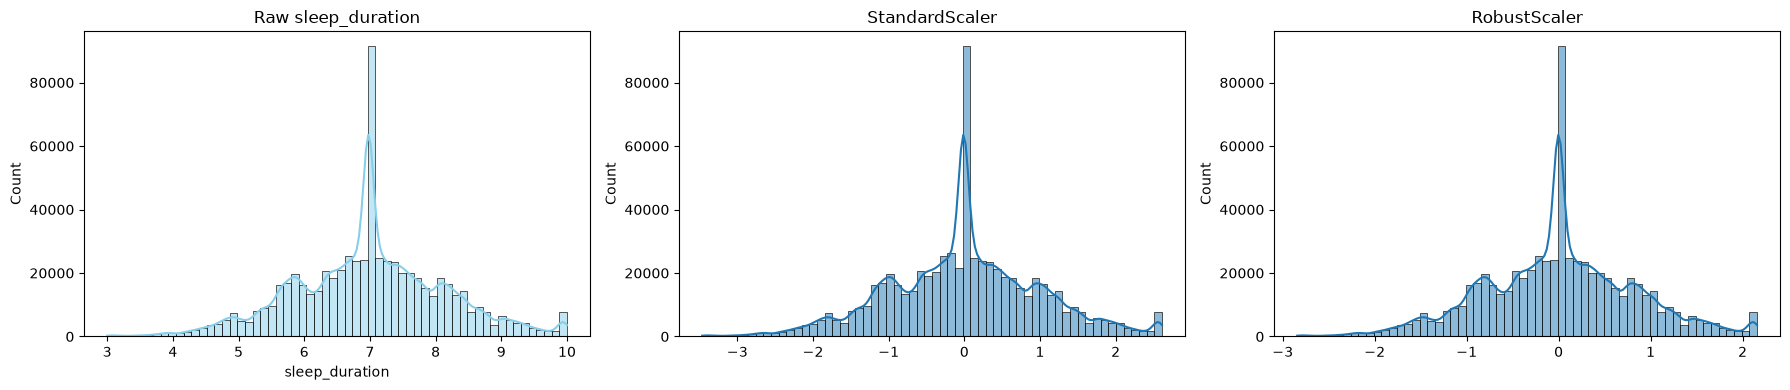

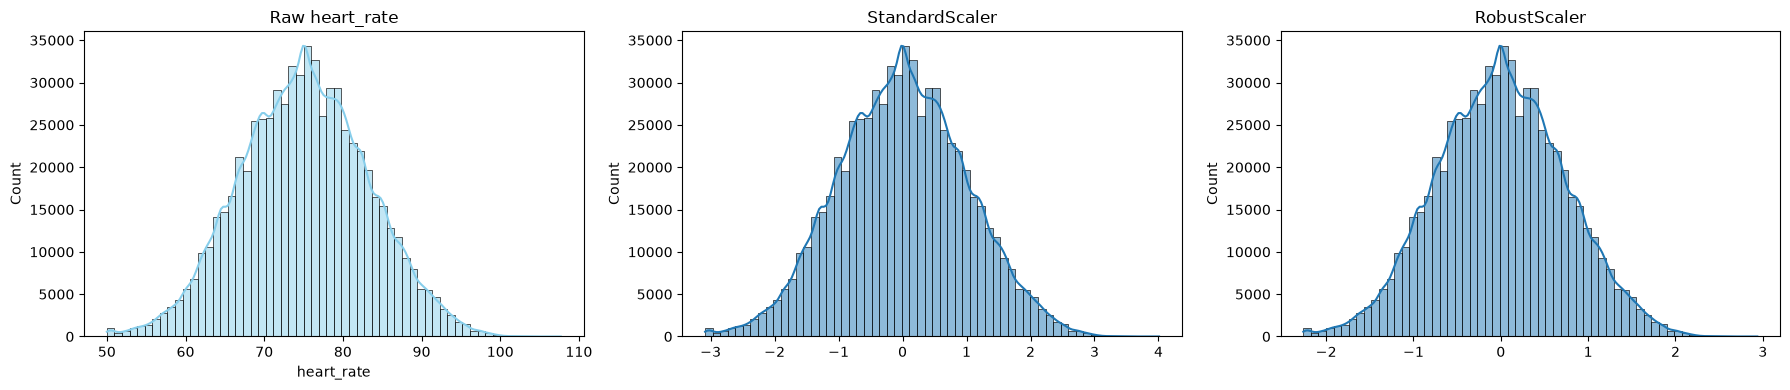

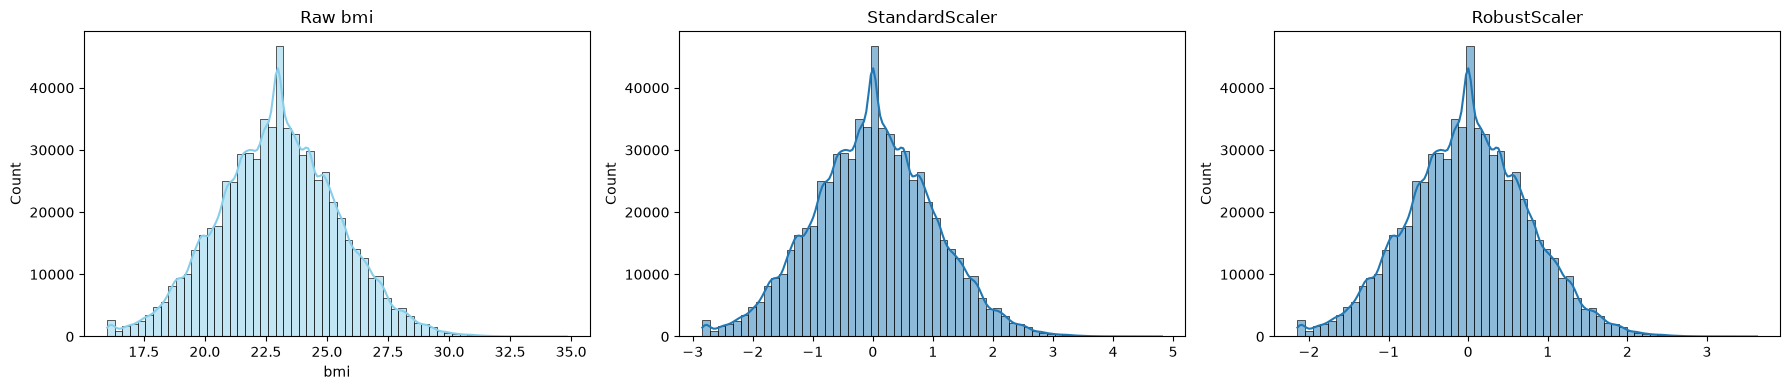

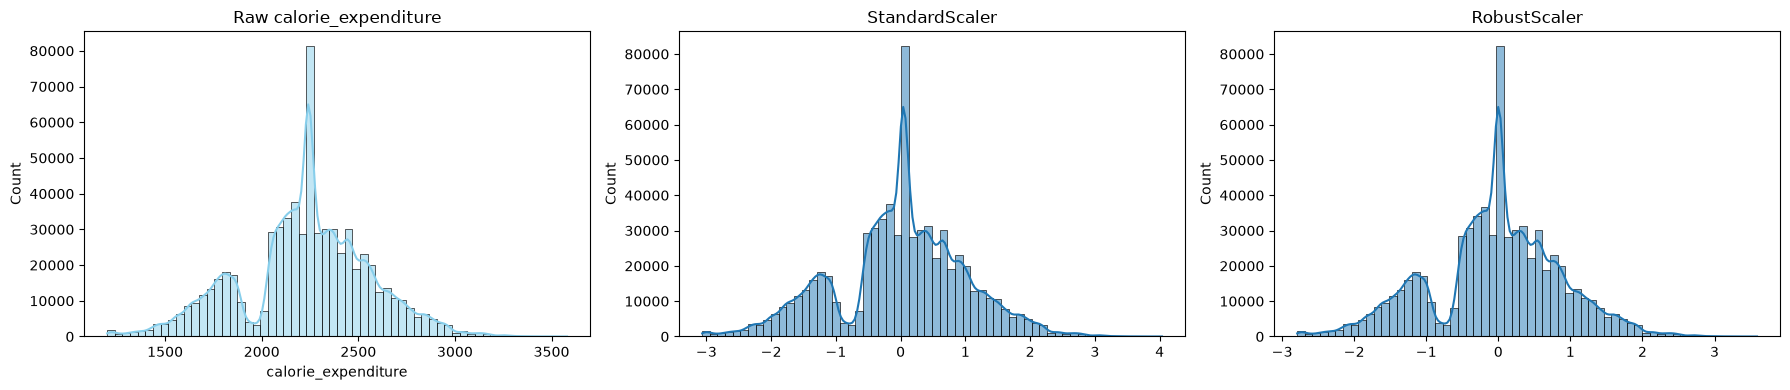

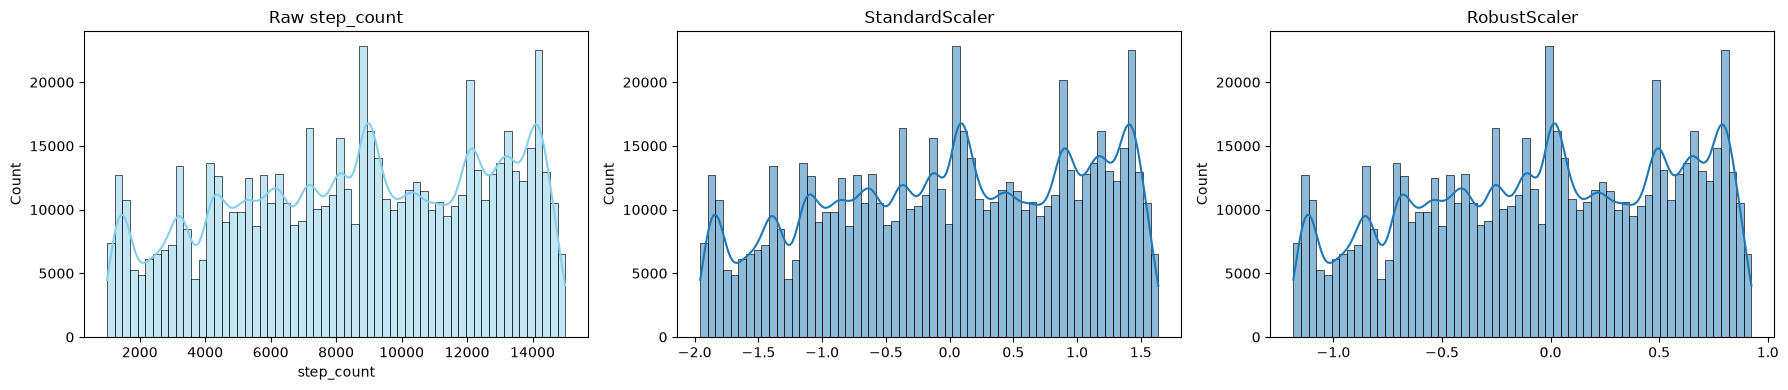

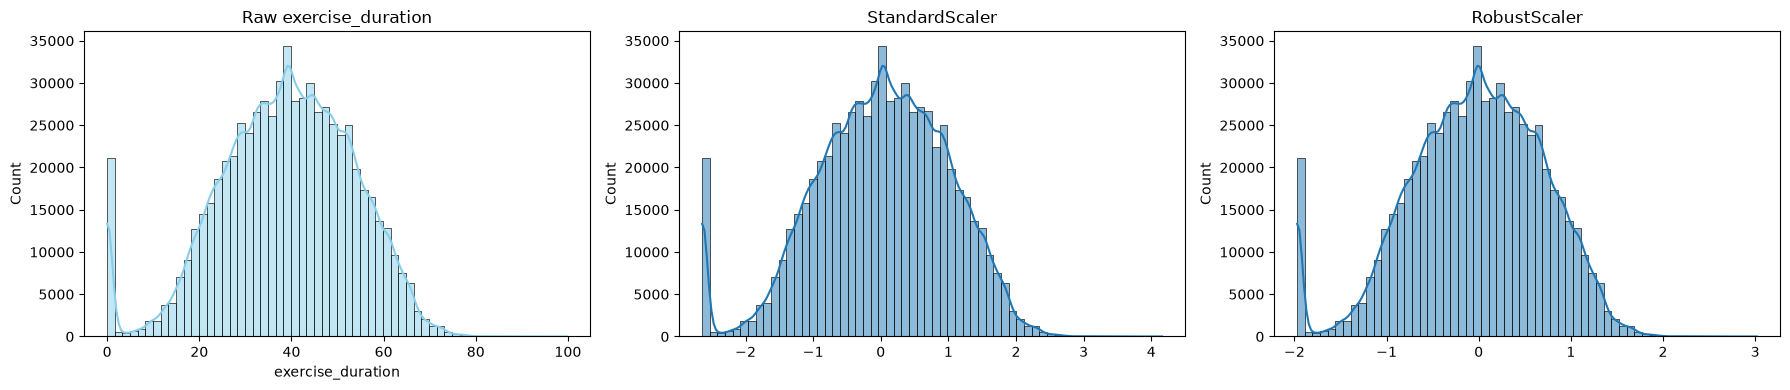

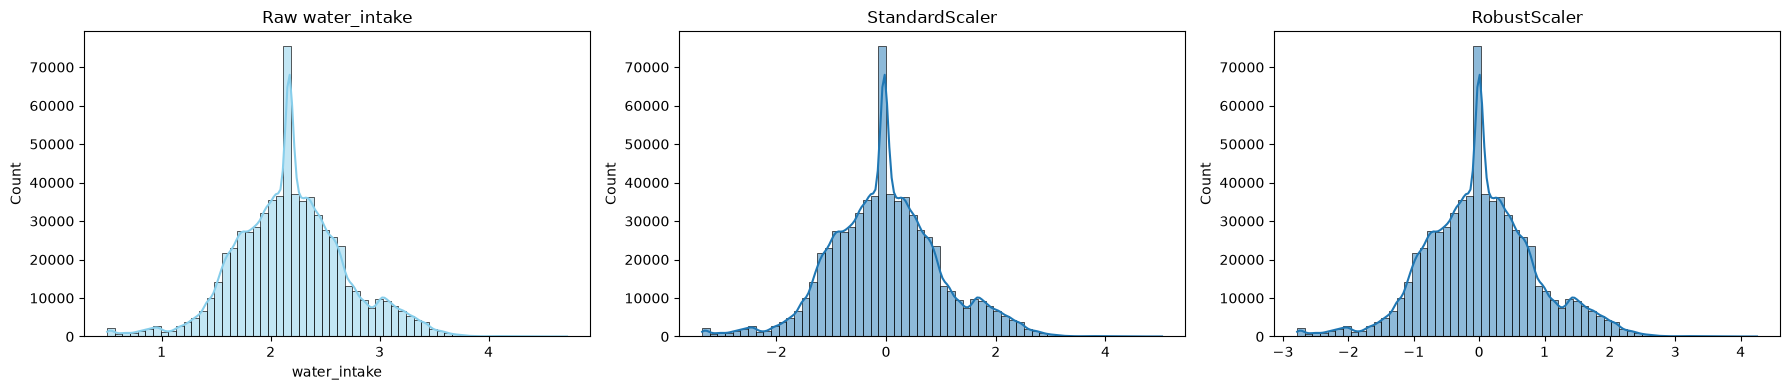

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_std = StandardScaler()
scaler_robust = RobustScaler()

columns = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure", 
           "step_count", "exercise_duration", "water_intake"]

for column in columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    sns.histplot(df[column], kde=True, bins=60, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Raw {column}')
    
    data_std = scaler_std.fit_transform(df[[column]])
    sns.histplot(data_std, kde=True, bins=60, ax=axes[1], color='salmon', legend=False)
    axes[1].set_title('StandardScaler')
    
    data_robust = scaler_robust.fit_transform(df[[column]])
    sns.histplot(data_robust, kde=True, bins=60, ax=axes[2], color='lightgreen', legend=False)
    axes[2].set_title('RobustScaler')
    
    plt.tight_layout()
    plt.show()

**Note:** normality testing of numeric features (Pearson chi-squared test) was moved to `02_statistical_tests.ipynb`.